### Iteration - 1 Failure demo

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import openpyxl
from sklearn.metrics import silhouette_score, silhouette_samples

file_path = r'C:\Users\DELL\Documents\SDH\Spotify\Spotify dataset\spotify_user_behaviout.xlsx'
df_user_behavior = pd.read_excel(file_path)

# CLUSTER_FEATURES_V1 = [
#     'daily_listening_minutes',  # usage intensity
#     'sessions_per_day',         # frequency
#     'days_active_last_30',      # consistency
#     'avg_session_minutes',      # depth
#     'skip_rate',                # content friction
#     'liked_songs_pct',          # positive engagement
#     'ads_skipped_pct'           # monetization friction
# ]


ModuleNotFoundError: No module named 'openpyxl'

In [0]:
# Build feature matrix X

X1 = base[CLUSTER_FEATURES_V1].copy()


In [0]:
km1 = KMeans(
    n_clusters = k,
    random_state = 42,
    n_init = 20,
    max_iter = 300
)


labels1 = km1.fit_predict(X1)
inertial = km1.inertia_

sil_avg_1= silhouette_score(X1, labels1)

print(f'Inertia: {round(inertial,2)}')
print(f' Silhoutte: {round(sil_avg_1,2)}')


Inertia: 53703427.73
 Silhoutte: 0.51


In [0]:
base_iter1 = base.copy()
base_iter1['cluster']= labels1
sizes1 = base_iter1['cluster'].value_counts().sort_index()
sizes1

cluster
0    64364
1    11069
2     1903
3    30664
Name: count, dtype: int64

In [0]:
means1 = (
    base_iter1.groupby('cluster')[CLUSTER_FEATURES_V1].mean().round(3)
)

In [0]:
profile1 = means1.copy()
profile1.insert(0, 'cluster_size', sizes1)
display(profile1)

cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
64364,19.856434853443687,1.141,20.711689530042907,18.354081362562315,0.351,0.2744512332066867,0.5173755690419698
11069,107.96818663461094,1.742,22.183715219449827,77.59498633456487,0.287,0.3036627994667376,0.5998217329265335
1903,229.9233986688061,3.869,23.02739336393134,80.98213577608956,0.284,0.3178919587448702,0.5776118309132263
30664,53.237406679166924,1.342,21.656940217144875,44.33973725715372,0.289,0.30257552562529083,0.5769627874496115


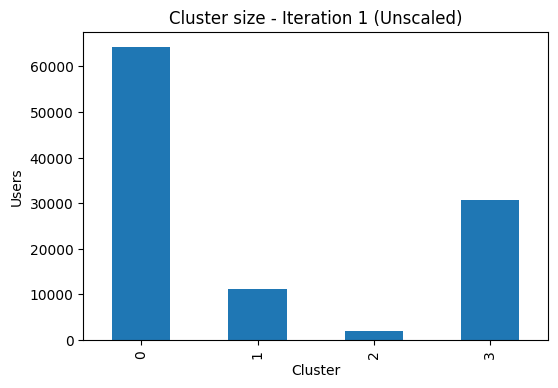

In [0]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,4))

base_iter1['cluster'].value_counts().sort_index().plot(kind= 'bar')
plt.title('Cluster size - Iteration 1 (Unscaled)')
plt.xlabel('Cluster')
plt.ylabel('Users')
plt.show()

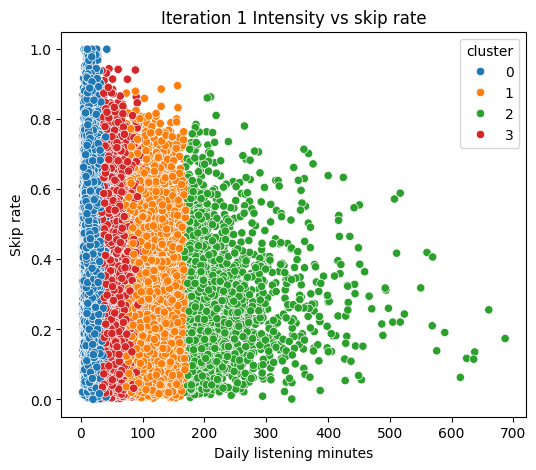

In [0]:
# scatter plot (No PCA)

# intensity vs skip
import seaborn as sns

plt.figure(figsize= (6,5))
sns.scatterplot(
    data = base_iter1,
    x = 'daily_listening_minutes',
    y = 'skip_rate',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration 1 Intensity vs skip rate')
plt.xlabel('Daily listening minutes')
plt.ylabel('Skip rate')
plt.show()

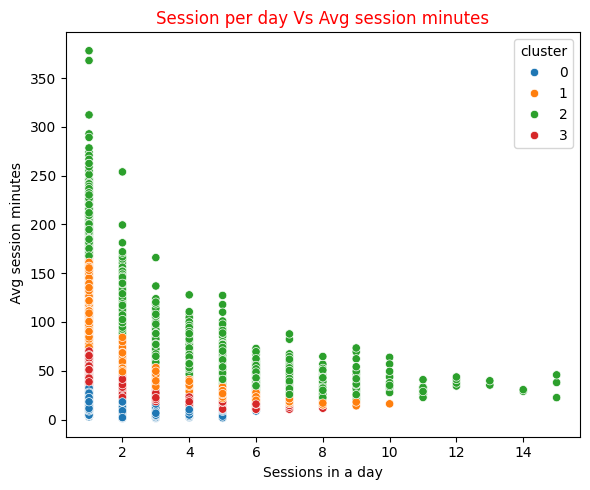

In [0]:
# frequency vs Session depth

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter1,
    x = 'sessions_per_day',
    y= 'avg_session_minutes',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Session per day Vs Avg session minutes', color = 'red')
plt.xlabel('Sessions in a day')
plt.ylabel(' Avg session minutes')
plt.tight_layout()
plt.show()

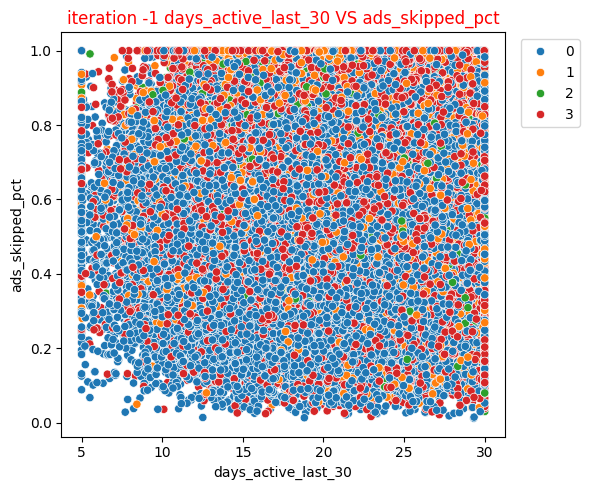

In [0]:
# consistance vs Ad friction

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter1,
    x = 'days_active_last_30',
    y= 'ads_skipped_pct',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('iteration -1 days_active_last_30 VS ads_skipped_pct', color = 'red')
plt.legend(bbox_to_anchor = (1.02, 1))
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

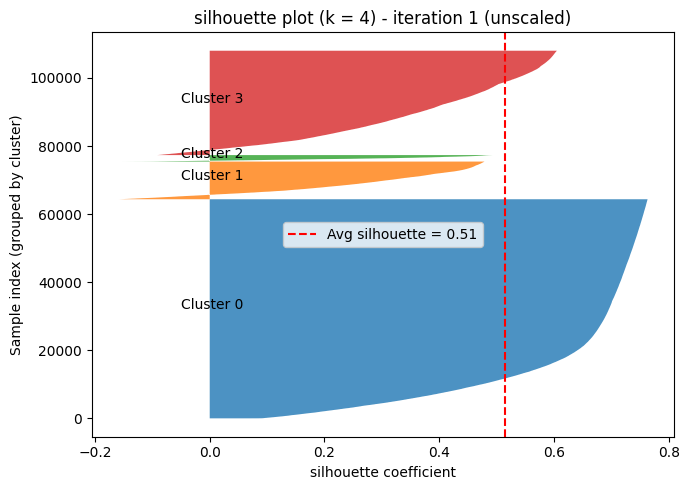

In [0]:
# silhouette Plot

sil_values_1 = silhouette_samples(X1, labels1)
sil_avg_1 = silhouette_score(X1, labels1)
plt.figure(figsize= (7,5))

y_lower = 0

vals0 = sil_values_1[labels1 == 0]
vals0.sort()
size0 = vals0.shape[0]

y_upper = y_lower + size0

plt.fill_betweenx(
    np.arange(y_lower, y_upper),    # vertical span
    0,                              # left boundary (silhoutte = 0)
    vals0,                          # right boundary (actual silhoutte values)
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5 * size0,  # slightly left of zero
    'Cluster 0'             # vertically centered
)

y_lower = y_upper

# Cluster 1
vals1 = sil_values_1[labels1==1]
vals1.sort()
size1 = vals1.shape[0]

y_upper = y_lower + size1

plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
    )
plt.text(-0.05,
         y_lower + 0.5 * size1, 'Cluster 1')

y_lower = y_upper

# cluster 2
vals2 = sil_values_1[labels1 == 2]
vals2.sort()

size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size2, 'Cluster 2')

y_lower = y_upper

# cluster 3
vals3 = sil_values_1[labels1 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size3, 'Cluster 3')

y_lower = y_upper

plt.axvline(
    x= sil_avg_1,
    color = 'red',
    linestyle = '--',
    label =f"Avg silhouette = {sil_avg_1:.2f}"
)

plt.title('silhouette plot (k = 4) - iteration 1 (unscaled)', color = 'red')
plt.xlabel('silhouette coefficient', color = 'purple')
plt.ylabel('Sample index (grouped by cluster)', color = 'purple')
plt.legend()
plt.tight_layout()
plt.show